# HW03 — Problem 2: Fashion-MNIST Image Classifier (PyTorch)

**Author:** Carlos Fernandez

This notebook reproduces the "Building an Image Classifier with PyTorch" section of Chapter 10 in *Hands-On Machine Learning with Scikit-Learn and PyTorch* (Geron, 2025): a 784-300-100-10 multilayer perceptron trained on Fashion-MNIST with plain stochastic gradient descent, validated during training on a held-out split, and evaluated on the test set exactly once at the end. It consolidates the seven standalone scripts from `prob1/scripts/` into a single, self-contained, top-to-bottom runnable notebook.

## 1. Imports and reproducibility setup

We import PyTorch, NumPy, and torchvision, then fix the seed for Python's `random`, NumPy, and PyTorch RNGs so the data split, weight initialization, and mini-batch shuffling are all reproducible. We also auto-select the best available device (CUDA, then Apple MPS, then CPU) so the notebook runs unchanged on any machine.

In [1]:
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2

%matplotlib inline

SEED = 42


def set_seed(seed: int = SEED) -> None:
    """Fix the seed for the random, numpy, and torch RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """Pick CUDA if available, else Apple MPS, else CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_seed(SEED)
device = get_device()

print(f"Python version:  {platform.python_version()}")
print(f"NumPy version:   {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Seed:            {SEED}")
print(f"Device:          {device}")

Python version:  3.11.16
NumPy version:   2.4.6
PyTorch version: 2.14.0+cpu
Seed:            42
Device:          cpu


## 2. Load Fashion-MNIST and build DataLoaders

We download Fashion-MNIST via torchvision (caching under `../prob1/data` so it isn't re-downloaded if the sibling `prob1` scripts already fetched it), convert images to float32 tensors scaled to `[0, 1]` with `transforms.v2` (`ToImage` + `ToDtype(scale=True)`), and split the 60,000 training images into 55,000 for training and 5,000 for validation using a seeded generator so the split is deterministic. The test set stays completely separate from this split and is not touched again until the final evaluation. DataLoaders use batch size 32, shuffling only the training set.

In [2]:
DATA_DIR = Path("../prob1/data").resolve()
BATCH_SIZE = 32
N_TRAIN = 55_000
N_VAL = 5_000

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

TRANSFORM = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)


def load_datasets(data_dir: Path = DATA_DIR):
    """Download (if needed) and return the raw train/test FashionMNIST datasets."""
    train_full = FashionMNIST(root=data_dir, train=True, download=True, transform=TRANSFORM)
    test = FashionMNIST(root=data_dir, train=False, download=True, transform=TRANSFORM)
    return train_full, test


def split_train_val(train_full, n_train: int = N_TRAIN, n_val: int = N_VAL, seed: int = SEED):
    """Split the full training set into train/validation subsets with a seeded generator."""
    generator = torch.Generator().manual_seed(seed)
    return random_split(train_full, [n_train, n_val], generator=generator)


def build_dataloaders(batch_size: int = BATCH_SIZE, data_dir: Path = DATA_DIR):
    """Load Fashion-MNIST, split it, and wrap the three subsets in DataLoaders."""
    train_full, test = load_datasets(data_dir)
    train, val = split_train_val(train_full)

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders()

print(f"Train size:      {len(train_loader.dataset)}")
print(f"Validation size: {len(val_loader.dataset)}")
print(f"Test size:       {len(test_loader.dataset)}")

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}, dtype: {images.dtype}")
print(f"Batch labels shape: {labels.shape}, dtype: {labels.dtype}")
print(f"Pixel value range:  [{images.min().item():.3f}, {images.max().item():.3f}]")
print(f"Class names: {CLASS_NAMES}")

Train size:      55000
Validation size: 5000
Test size:       10000
Batch images shape: torch.Size([32, 1, 28, 28]), dtype: torch.float32
Batch labels shape: torch.Size([32]), dtype: torch.int64
Pixel value range:  [0.000, 1.000]
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Define the 784-300-100-10 MLP

`ImageClassifier` flattens the 28x28 image into a 784-vector, passes it through two hidden layers (300 and 100 units) with ReLU activations, and outputs 10 raw logits — no softmax, since `CrossEntropyLoss` applies `log_softmax` internally and expects raw scores. We sanity-check the architecture on a dummy batch: the output shape must be `(batch, 10)` and the model must have exactly 266,610 parameters.

In [3]:
EXPECTED_PARAM_COUNT = 266_610


class ImageClassifier(nn.Module):
    """784-300-100-10 MLP that returns raw logits over 10 classes."""

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(784, 300)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.hidden1(x))
        x = self.relu2(self.hidden2(x))
        return self.output(x)


def build_model() -> ImageClassifier:
    """Construct an ImageClassifier instance."""
    return ImageClassifier()


def count_parameters(model: nn.Module) -> int:
    """Total number of parameters (trainable and not) in the model."""
    return sum(p.numel() for p in model.parameters())


_sanity_model = build_model()
_dummy_input = torch.rand(32, 1, 28, 28)
_logits = _sanity_model(_dummy_input)
assert _logits.shape == (32, 10), f"Unexpected output shape: {_logits.shape}"

_n_params = count_parameters(_sanity_model)
assert _n_params == EXPECTED_PARAM_COUNT, f"Expected {EXPECTED_PARAM_COUNT} parameters, got {_n_params}"

print(_sanity_model)
print(f"Output shape: {tuple(_logits.shape)}")
print(f"Total parameters: {_n_params}")
print("Model sanity checks passed.")

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=100, out_features=10, bias=True)
)
Output shape: (32, 10)
Total parameters: 266610
Model sanity checks passed.


## 4. Training and evaluation functions

`train_one_epoch` runs one pass over the training data: it zeros gradients before every batch (`optimizer.zero_grad()`), computes `CrossEntropyLoss` on the raw logits, backpropagates, and steps the SGD optimizer. `evaluate` mirrors the same loss/accuracy bookkeeping but wraps everything in `model.eval()` and `torch.no_grad()` so no gradients are tracked during validation/test inference. `train_model` ties the two together for a fixed number of epochs, recording train and validation loss and accuracy after every epoch.

In [4]:
LEARNING_RATE = 0.1
N_EPOCHS = 10


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one training epoch; return (avg_loss, accuracy)."""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate the model on a loader (no gradients); return (avg_loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader, device, epochs=N_EPOCHS, lr=LEARNING_RATE):
    """Train for `epochs` epochs with SGD, printing one line per epoch.

    Returns a history dict with train_loss, train_acc, val_loss, val_acc lists.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:2d}/{epochs} - "
            f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
            f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
        )

    return history

## 5. Train the model (SGD, lr=0.1, 10 epochs)

We build a fresh `ImageClassifier`, move it to the selected device, and train it for exactly 10 epochs with plain SGD at a learning rate of 0.1, printing one line of train/validation loss and accuracy per epoch. This is the only training run in the notebook — every later cell (plotting, test evaluation, checkpointing) reuses this same trained model instead of retraining, so results stay consistent throughout.

In [5]:
set_seed(SEED)

model = build_model().to(device)
history = train_model(model, train_loader, val_loader, device)

print(f"\nFinal validation accuracy: {history['val_acc'][-1]:.4f}")

Epoch  1/10 - train_loss: 0.6062 - train_acc: 0.7812 - val_loss: 0.4433 - val_acc: 0.8420


Epoch  2/10 - train_loss: 0.4060 - train_acc: 0.8492 - val_loss: 0.4289 - val_acc: 0.8388


Epoch  3/10 - train_loss: 0.3631 - train_acc: 0.8655 - val_loss: 0.3957 - val_acc: 0.8524


Epoch  4/10 - train_loss: 0.3348 - train_acc: 0.8768 - val_loss: 0.3650 - val_acc: 0.8650


Epoch  5/10 - train_loss: 0.3142 - train_acc: 0.8840 - val_loss: 0.3350 - val_acc: 0.8788


Epoch  6/10 - train_loss: 0.2994 - train_acc: 0.8873 - val_loss: 0.3561 - val_acc: 0.8662


Epoch  7/10 - train_loss: 0.2851 - train_acc: 0.8931 - val_loss: 0.3400 - val_acc: 0.8736


Epoch  8/10 - train_loss: 0.2744 - train_acc: 0.8961 - val_loss: 0.3390 - val_acc: 0.8758


Epoch  9/10 - train_loss: 0.2634 - train_acc: 0.9014 - val_loss: 0.3316 - val_acc: 0.8810


Epoch 10/10 - train_loss: 0.2535 - train_acc: 0.9035 - val_loss: 0.3518 - val_acc: 0.8750

Final validation accuracy: 0.8750


## 6. Plot training and validation curves

We plot accuracy and loss per epoch side by side (train vs. validation on each) to visualize learning progress and check for overfitting — a widening gap between train and validation accuracy over epochs would be the signal to watch for.

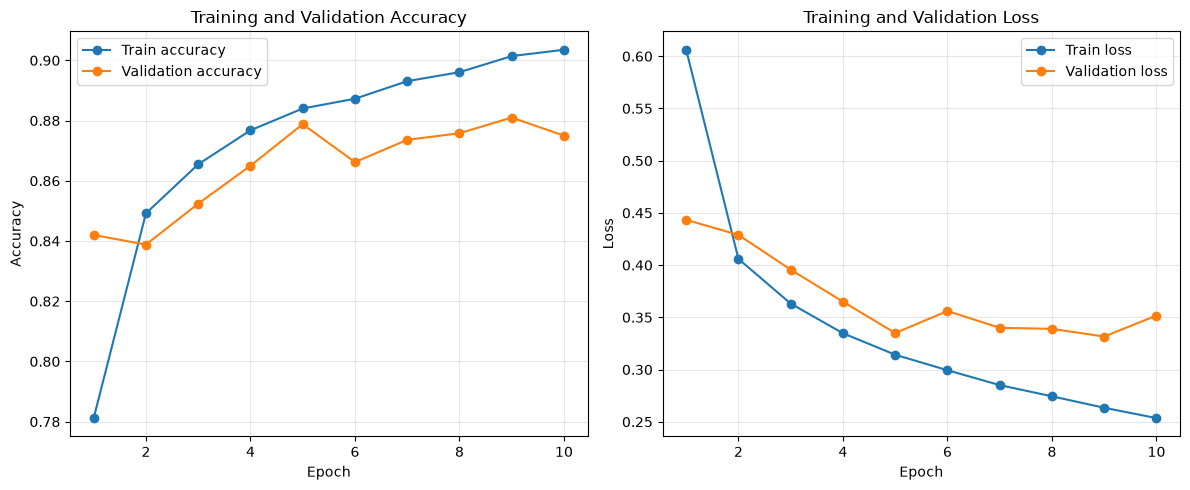

In [6]:
def plot_training_curves(history: dict):
    """Plot accuracy and loss curves (train + val) side by side."""
    epochs = range(1, len(history["train_acc"]) + 1)

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 5))

    ax_acc.plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
    ax_acc.plot(epochs, history["val_acc"], marker="o", label="Validation accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title("Training and Validation Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    ax_loss.plot(epochs, history["train_loss"], marker="o", label="Train loss")
    ax_loss.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Training and Validation Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


plot_training_curves(history)

## 7. Evaluate on the test set (used once)

The test set is reserved for a single, final, unbiased performance estimate — it was never used for training or for any validation-based decisions. We report overall test accuracy, then show the true class, predicted class, and top-3 softmax probabilities for 3 individual test images. Softmax is applied only here, to turn logits into human-readable probabilities for reporting — never before the training loss, which always operates on raw logits.

In [7]:
TOP_K = 3
N_SAMPLES = 3


@torch.no_grad()
def test_accuracy(model, test_loader, device) -> float:
    """Compute accuracy on the test set. Intended to be called once, after training."""
    criterion = nn.CrossEntropyLoss()
    _, accuracy = evaluate(model, test_loader, criterion, device)
    return accuracy


@torch.no_grad()
def predict_samples(model, dataset, indices, device, class_names=CLASS_NAMES, top_k=TOP_K):
    """For each index into `dataset`, return the true/predicted class and top-k softmax probs."""
    model.eval()
    results = []

    for idx in indices:
        image, true_label = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1).squeeze(0)
        top_probs, top_classes = probs.topk(top_k)
        predicted_label = int(top_classes[0].item())

        results.append(
            {
                "index": idx,
                "true_class": class_names[true_label],
                "predicted_class": class_names[predicted_label],
                "top_k": [(class_names[int(c)], float(p)) for p, c in zip(top_probs, top_classes)],
            }
        )

    return results


acc = test_accuracy(model, test_loader, device)
print(f"Test accuracy: {acc:.4f}")

sample_indices = list(range(N_SAMPLES))
predictions = predict_samples(model, test_loader.dataset, sample_indices, device)

print(f"\nSample predictions (top-{TOP_K} softmax probabilities):")
for pred in predictions:
    print(f"\n  Test image #{pred['index']}")
    print(f"    True class:      {pred['true_class']}")
    print(f"    Predicted class: {pred['predicted_class']}")
    for class_name, prob in pred["top_k"]:
        print(f"      {class_name:<14s} {prob:.4f}")

Test accuracy: 0.8692

Sample predictions (top-3 softmax probabilities):

  Test image #0
    True class:      Ankle boot
    Predicted class: Ankle boot
      Ankle boot     0.9902
      Sneaker        0.0098
      Sandal         0.0001

  Test image #1
    True class:      Pullover
    Predicted class: Pullover
      Pullover       0.9983
      Coat           0.0015
      Shirt          0.0002

  Test image #2
    True class:      Trouser
    Predicted class: Trouser
      Trouser        1.0000
      T-shirt/top    0.0000
      Shirt          0.0000


## 8. Save and reload the model checkpoint

To confirm the trained model can be persisted and restored correctly, we save its `state_dict` together with the architecture's constructor hyperparameters, reload the checkpoint with `torch.load(..., weights_only=True)` (the safe-unpickling mode that only allows tensors and basic Python types, never arbitrary code execution), rebuild the model via `build_model()`, and assert that the reloaded model produces bit-identical outputs to the original on the same input.

In [8]:
CHECKPOINT_PATH = Path("model_checkpoint.pt")

HYPERPARAMETERS = {
    "input_size": 784,
    "hidden1_size": 300,
    "hidden2_size": 100,
    "num_classes": 10,
}


def save_checkpoint(model: ImageClassifier, path: Path = CHECKPOINT_PATH, hyperparameters: dict = HYPERPARAMETERS) -> Path:
    """Save the model's state_dict plus its constructor hyperparameters."""
    checkpoint = {"state_dict": model.state_dict(), "hyperparameters": hyperparameters}
    torch.save(checkpoint, path)
    return path


def load_checkpoint(path: Path = CHECKPOINT_PATH, device: torch.device = torch.device("cpu")):
    """Reload a checkpoint saved by save_checkpoint using the safe weights_only mode."""
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    reloaded = build_model().to(device)
    reloaded.load_state_dict(checkpoint["state_dict"])
    return reloaded, checkpoint["hyperparameters"]


model.eval()
dummy_batch = torch.rand(4, 1, 28, 28, device=device)
with torch.no_grad():
    original_output = model(dummy_batch)

saved_path = save_checkpoint(model)
print(f"Saved checkpoint to {saved_path.resolve()}")

reloaded_model, reloaded_hyperparameters = load_checkpoint(saved_path, device)
reloaded_model.eval()
print(f"Reloaded hyperparameters: {reloaded_hyperparameters}")
assert reloaded_hyperparameters == HYPERPARAMETERS, "Hyperparameters changed across save/load"

with torch.no_grad():
    reloaded_output = reloaded_model(dummy_batch)

assert torch.equal(original_output, reloaded_output), "Reloaded model output differs from original"
print("Reloaded model output is identical to the original. All assertions passed.")

Saved checkpoint to C:\Users\cafe\CSCI89\hw03\csci-e89-hw03\prob2\model_checkpoint.pt
Reloaded hyperparameters: {'input_size': 784, 'hidden1_size': 300, 'hidden2_size': 100, 'num_classes': 10}
Reloaded model output is identical to the original. All assertions passed.
